# Renewable Energy Forecasting – Example Notebook

In this notebook I demonstrate the baseline pipeline for the renewable energy forecasting project. I load the processed dataset, inspect it briefly, train a simple model, and compute MAE and RMSE on a validation split.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# I am inside examples/, so the project root is the parent directory
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

PROJECT_ROOT, PROCESSED_DIR


(PosixPath('/work/class_project/MSML610/Fall2025/projects/UmdTask15_Fall2025_Renewable_Energy_Production'),
 PosixPath('/work/class_project/MSML610/Fall2025/projects/UmdTask15_Fall2025_Renewable_Energy_Production/data/processed'))

In [3]:
train_path = PROCESSED_DIR / "train.csv"
df = pd.read_csv(train_path)

df.head()


,timestamp,energy_mwh,temp_c,cloud_cover,solar_radiation,wind_speed,year,month,day,day_of_week,hour,is_weekend
0,2024-01-01 00:00:00,0.319,-2.66,0.338,0.0,3.32,2024,1,1,0,0,0
1,2024-01-01 01:00:00,0.491,-2.26,0.410,0.0,3.89,2024,1,1,0,1,0
2,2024-01-01 02:00:00,0.593,1.40,0.526,0.0,4.42,2024,1,1,0,2,0
3,2024-01-01 03:00:00,0.048,-1.41,0.414,0.0,3.94,2024,1,1,0,3,0
4,2024-01-01 04:00:00,0.000,1.97,0.564,0.0,2.96,2024,1,1,0,4,0


In [4]:
target_col = "energy_mwh"

y = df[target_col]
X = df.drop(columns=[target_col])

# Use only numeric features
X = X.select_dtypes(include=[np.number])

# Time-aware split: last 20% as validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False,
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

preds = model.predict(X_valid)

mae = mean_absolute_error(y_valid, preds)
rmse = mean_squared_error(y_valid, preds, squared=False)

print(f"Number of training samples:   {len(X_train)}")
print(f"Number of validation samples: {len(X_valid)}")
print(f"Validation MAE:  {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")


Number of training samples:   3456
Number of validation samples: 864
Validation MAE:  0.4206
Validation RMSE: 0.5287


## 1. Quick data inspection

In this section I quickly check the structure of the processed dataset. I want to confirm the number of rows and columns, the data types, and basic summary statistics for the features and the target `energy_mwh`.


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        4320 non-null   object 
 1   energy_mwh       4320 non-null   float64
 2   temp_c           4320 non-null   float64
 3   cloud_cover      4320 non-null   float64
 4   solar_radiation  4320 non-null   float64
 5   wind_speed       4320 non-null   float64
 6   year             4320 non-null   int64  
 7   month            4320 non-null   int64  
 8   day              4320 non-null   int64  
 9   day_of_week      4320 non-null   int64  
 10  hour             4320 non-null   int64  
 11  is_weekend       4320 non-null   int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 405.1+ KB


In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
energy_mwh,4320.0,9.254237,11.783243,0.000,0.0000,0.886,17.856,48.16
temp_c,4320.0,9.961979,7.405680,-5.640,3.3675,10.000,16.480,26.07
cloud_cover,4320.0,0.429902,0.229186,0.004,0.2530,0.405,0.585,1.00
solar_radiation,4320.0,0.182390,0.237521,0.000,0.0000,0.000,0.357,0.95
wind_speed,4320.0,3.314627,1.039473,0.000,2.6000,3.300,4.000,7.32
year,4320.0,2024.000000,0.000000,2024.000,2024.0000,2024.000,2024.000,2024.00
month,4320.0,3.472222,1.698007,1.000,2.0000,3.000,5.000,6.00
day,4320.0,15.522222,8.694206,1.000,8.0000,15.500,23.000,31.00
day_of_week,4320.0,2.972222,1.993081,0.000,1.0000,3.000,5.000,6.00
hour,4320.0,11.500000,6.922988,0.000,5.7500,11.500,17.250,23.00


## 2. Target behaviour over time

Before fitting any model, I look at how the target `energy_mwh` evolves over time. This helps me get an intuition about the scale, variability, and any obvious patterns in the series.


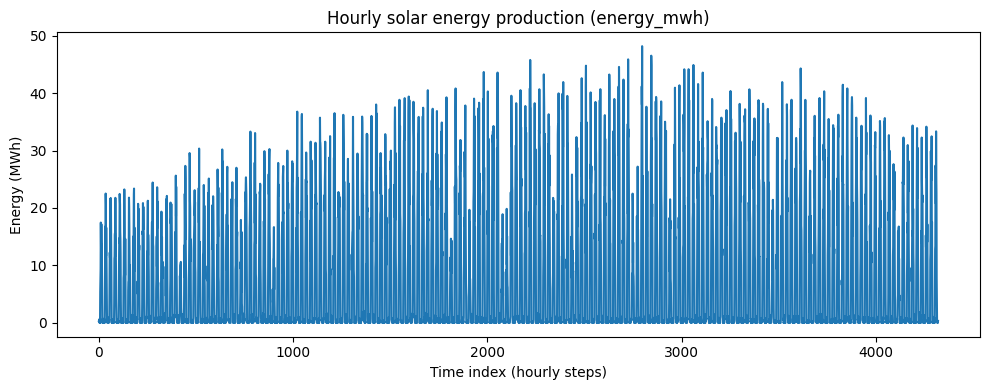

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(df["energy_mwh"].values)
plt.xlabel("Time index (hourly steps)")
plt.ylabel("Energy (MWh)")
plt.title("Hourly solar energy production (energy_mwh)")
plt.tight_layout()
plt.show()


## 3. Predictions vs actual values

To understand how the model behaves over time, I compare the predicted values against the actual `energy_mwh` values on the validation set.


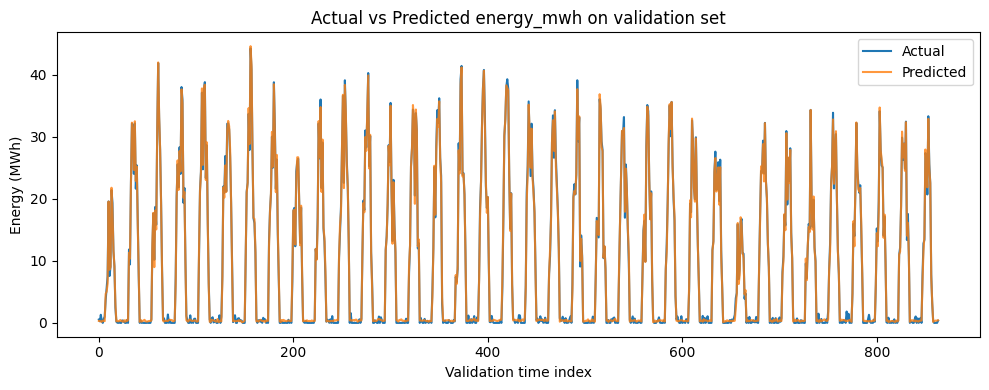

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(y_valid.values, label="Actual")
plt.plot(preds, label="Predicted", alpha=0.8)
plt.xlabel("Validation time index")
plt.ylabel("Energy (MWh)")
plt.title("Actual vs Predicted energy_mwh on validation set")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Feature importance

Since I am using a tree-based model (Random Forest), I can inspect feature importances to see which variables the model finds most useful for forecasting `energy_mwh`.


In [11]:
importances = model.feature_importances_
feature_names = X.columns

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
fi


solar_radiation    0.998517
wind_speed         0.000306
temp_c             0.000294
cloud_cover        0.000288
day                0.000257
hour               0.000142
day_of_week        0.000124
month              0.000058
is_weekend         0.000014
year               0.000000
dtype: float64

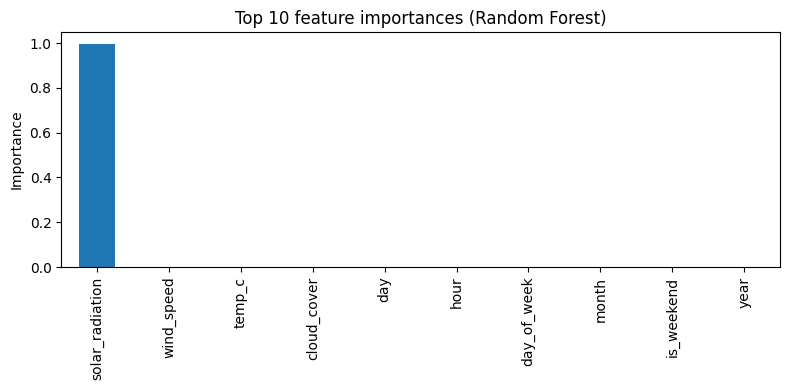

In [12]:
plt.figure(figsize=(8, 4))
fi.head(10).plot(kind="bar")
plt.ylabel("Importance")
plt.title("Top 10 feature importances (Random Forest)")
plt.tight_layout()
plt.show()


## 5. Summary

In this notebook I:

- Loaded the processed dataset `train.csv`, which contains the target `energy_mwh` along with weather variables and simple time-based features.
- Performed a quick sanity check of the data structure and summary statistics.
- Visualized the behaviour of `energy_mwh` over time to get an intuition about the signal.
- Trained a baseline Random Forest regressor using an 80/20 time-aware split (no shuffling).
- Evaluated the model using MAE and RMSE, and visualized predicted vs actual values on the validation set.
- Inspected feature importances to understand which inputs were most useful for the model.

This gives me a clean, end-to-end baseline for the renewable energy forecasting task. Later, I can compare more advanced models (e.g., XGBoost, sequence models) and richer features (lags, rolling statistics) against this baseline.
